# ToDo MVP:
- Importing data 

- Defining classes ( try only with Strong PYT && Decoy 1 / Decoy 7)
- Define model 

- Define Loss
- Defin minimization algorithm 
- Fit

- Inspect expected trends
- Visualize results (comparison)

In [24]:
# Standard libraries used throughout the notebook
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import seaborn as sns
import itertools
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import math
import model_database as db
import simulation_core as sim
import warnings
from scipy.optimize import minimize
import fitting_core_MVP as fit
# To use directely module variation
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Import data

In [2]:


# --------------------------------------------------------------------------
# PARAMETER — PATH_DATASET
# --------------------------------------------------------------------------

PATH_RAW_DATASET = r"C:\Users\marco\Desktop\Tesi\.LabWork\Data\Data from Suzanne\fitness_calc_PB_H3B.xlsx"
PATH_LOG_READS_NORMALIZED = r"C:/Users/marco/Desktop/Tesi/.LabWork/Results/log_reads_norm.csv"
PATH_LFC = "C:/Users/marco/Desktop/Tesi/.LabWork/Results/lfc_results.csv"
# We load the raw file with no changes.
# data_raw will never be modified — it stays as the original reference.
data_raw = pd.read_excel(PATH_RAW_DATASET)
data_reads_norm = pd.read_csv(PATH_LOG_READS_NORMALIZED)
data_lfc = pd.read_csv(PATH_LFC)

data_reads_norm.columns = data_reads_norm.columns.str.replace(
    "output_", "norm_reads_", regex=False
)

data_lfc.drop(columns=["DECOY", "PYT", "ANCHOR"], inplace=True)

# --------------------------------------------------------------------------
# Data Merging ( unify the datasets)
# --------------------------------------------------------------------------
df_CLR_norm = pd.merge(data_reads_norm, data_lfc, on="seq_id")
df_CLR_norm['seq_id'] = df_CLR_norm['seq_id'].astype(int)
data = pd.merge(data_raw, df_CLR_norm, on="seq_id")
# --------------------------------------------------------------------------
# Data Filtering
# --------------------------------------------------------------------------

MIN_READS_THRESHOLD = 50

n_total   = len(data_raw)
mask_ok   = data["Input_counts"] >= MIN_READS_THRESHOLD
n_removed = (~mask_ok).sum()
n_kept    = mask_ok.sum()

data_filtered = data[mask_ok].copy().reset_index(drop=True)
data_filtered['ANCHOR'] = data_filtered['ANCHOR'].astype(str)


variables = [ 'DECOY', 'PYT']
lfc = [col for col in data_filtered.columns if 'lfc' in col]
normalized = [col for col in data_filtered.columns if 'norm_reads' in col]

focus_cols = ['seq_id', *variables, *lfc, *normalized]
df_lfc = data_filtered.loc[:, focus_cols]




unique_values = [df_lfc[col].dropna().unique() for col in variables]
combinations_names = list(itertools.product(*unique_values))

stratified_data =  {}
for key_classes, subset in df_lfc.groupby(variables):
    stratified_data[key_classes] = subset.drop(
        columns = variables
    )



# --------------------------------------------------------------------------
# CONSTANT definition
# --------------------------------------------------------------------------
DRUG_CONCENTRATIONS_raw = [1e-11, 1e-10, 2e-10, 4e-10, 1e-09]
def scale_drug_concentration(drug_linear, 
                             min_real=1e-11, 
                             max_real=1e-9, 
                             min_scaled=0., 
                             max_scaled=100.0):
    """
    Scala la concentrazione lineare del farmaco in un range lineare personalizzato (es. 1-100)
    passando prima per lo spazio logaritmico, per preservare la sensibilità alle basse dosi.
    """
    # 1. Passaggio allo spazio logaritmico (esponenti)
    log_drug = np.log10(drug_linear)
    log_min = np.log10(min_real)  # -11
    log_max = np.log10(max_real)  # -9
    
    # 2. Traslazione e riscalamento lineare dell'esponente nel nuovo range [min_scaled, max_scaled]
    drug_scaled = min_scaled + (log_drug - log_min) * (max_scaled - min_scaled) / (log_max - log_min)
    
    return drug_scaled

DRUG_CONCENTRATIONS = scale_drug_concentration(DRUG_CONCENTRATIONS_raw)




## Define classes - model - expected trends

In [30]:
no_decoy_class = stratified_data[('Decoy 7', 'Strong')]
max_decoy_class = stratified_data[('Decoy 1', 'Strong')]

model_3 = 'k_1[linear_increase]__3nodes'
model_4 = 'k3[linear_decrease]__4nodes'




# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt
# from sklearn.cluster import KMeans

# # Assuming your DataFrame is named 'no_decoy_class'

# # 1. Define the number of distinct behavior patterns you want to find
# n_clusters = 10
# kmeans = KMeans(n_clusters=n_clusters, random_state=42)

# # 2. Fit the model and assign each sequence to a specific cluster group
# df_with_clusters = no_decoy_class.copy()
# df_with_clusters['cluster'] = kmeans.fit_predict(no_decoy_class)

# # 3. Calculate the average LFC for each cluster group
# cluster_means = df_with_clusters.groupby('cluster').mean()

# # 4. Plot the heatmap of the distinct behavioral trends
# ax = sns.heatmap(
#     cluster_means,
#     cmap='coolwarm',
#     center=0,
#     annot=True,           # Display the exact average LFC values inside cells
#     fmt=".2f",            # Round numbers to 2 decimal places
#     xticklabels=True,
#     yticklabels=True
# )

# # 5. Save the plot using the figure object
# ax.get_figure().savefig("heatmap_behavior_profiles.png", dpi=300)


## Execution -- 4 state Model (k3 linear decrease) -- max decoy class

In [41]:
n_start = 100

In [42]:
best_fit_maxdecoy, fit_history_maxdecoy, fit_dictionary_maxdecoy = fit.multistart_fit(data = max_decoy_class,
               free_param_names = ['k1', 'k2', 'k_1', 'k_2', 'k3', 'k4', 'alpha'],
               vector_conc_without_control = DRUG_CONCENTRATIONS[1:],
               model_name = 'k3[linear_decrease]__4nodes',
               fixed_params = None,
               n_starts = n_start,
               log_bounds = (-3,3),
               show_history = True,
               show_messages= False,
               show_dict = True
               )

c:\Users\marco\Desktop\Tesi\.LabWork\Code\5. Fitting\fitting_core_MVP.py:114: UserWarning: The following parameters were missing and have been automatically set to 0: beta
  params = _param_array_to_dict(free_parameters_values, free_param_names, fixed_params)


## Execution -- 4 state Model (k3 linear decrease) -- No decoy class -- FIX k2 and k_2 to 0!.

In [43]:
n_start = 100

In [44]:
best_fit_nodecoy, fit_history_nodecoy, fit_dictionary_nodecoy = fit.multistart_fit(data = no_decoy_class,
               free_param_names = ['k1',  'k_1', 'k3', 'k4', 'alpha'],
               vector_conc_without_control = DRUG_CONCENTRATIONS[1:],
               model_name = 'k3[linear_decrease]__4nodes',
               fixed_params = {'k2' : 0, 'k_2': 0},
               n_starts = n_start,
               log_bounds = (-3,3),
               show_history = True,
               show_messages= False,
               show_dict = True
               )

## Check 1: Optimization Dignostic (nodecoy )


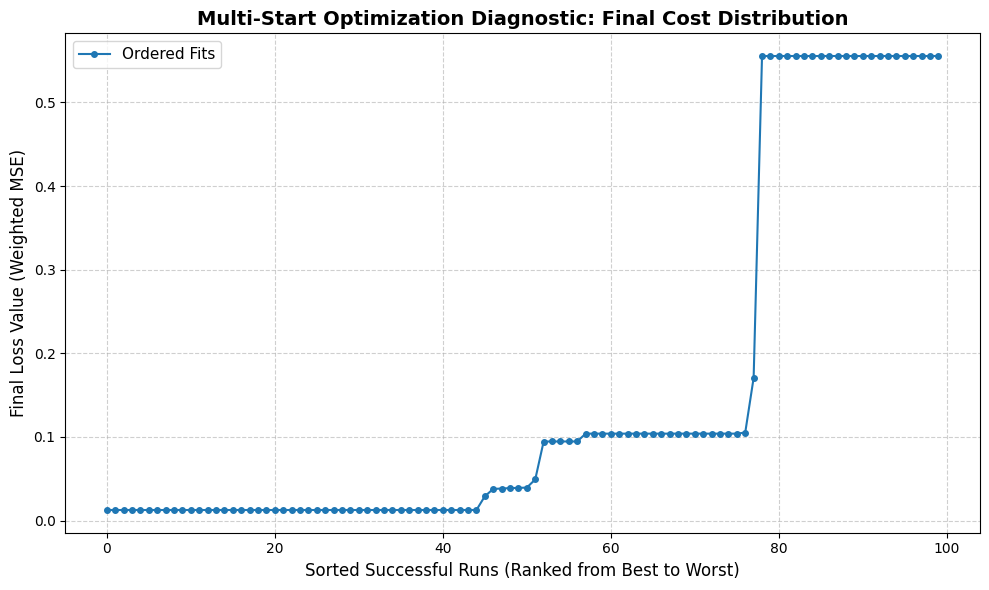

In [45]:

# 1. Filter for successful optimization runs
successful_runs = fit_history_nodecoy[fit_history_nodecoy['success'] == True].copy()

# 2. Sort the runs by final cost from lowest (best) to highest
successful_runs_sorted = successful_runs.sort_values(by='final_cost').reset_index(drop=True)

# 3. Create the plot
plt.figure(figsize=(10, 6))

# Plotting as both lines and points for clear visualization
plt.plot(successful_runs_sorted.index, successful_runs_sorted['final_cost'], 
         linestyle='-', marker='o', color='#1f77b4', markersize=4, label='Ordered Fits')

# Add titles and labels in B2 English
plt.title('Multi-Start Optimization Diagnostic: Final Cost Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Sorted Successful Runs (Ranked from Best to Worst)', fontsize=12)
plt.ylabel('Final Loss Value (Weighted MSE)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)

# Display the plot
plt.tight_layout()
plt.show()

## Check 2: Parameter ranges exploration

Tabella parametri per classe
Una tabella semplice: righe = classi, colonne = parametri fittati. Già leggibile così. L'interpretazione che puoi fare subito:

k_1 (o il parametro modulato) cambia tra classi? → il farmaco agisce diversamente su sequenze diverse
I parametri cinetici di base (k1, k2, k_2) sono ordinati biologicamente? → decoy1 dovrebbe avere k_2 più bassa di decoy7

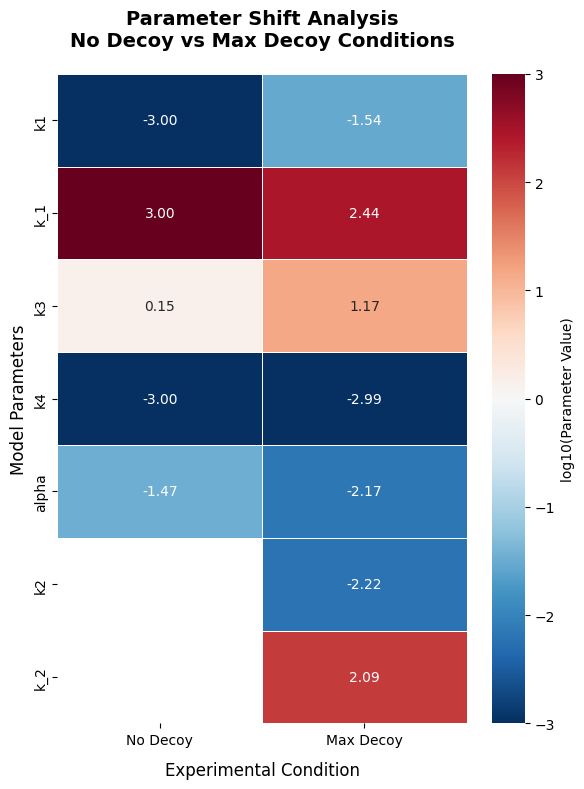

In [46]:

# 2. Creiamo il DataFrame combinando i due dizionari
df_compare = pd.DataFrame(
    {'No Decoy': fit_dictionary_nodecoy, 'Max Decoy': fit_dictionary_maxdecoy}
)

# 3. Creazione del Plot
plt.figure(figsize=(6, 8))

# Disegniamo la heatmap
# vmin e vmax specchiano i tuoi log_bounds (-3, 3) per dare consistenza al colore
sns.heatmap(
    df_compare,
    annot=True,  # Mostra il valore numerico dentro la cella
    fmt=".2f",  # Arrotonda a due cifre decimali
    cmap="RdBu_r",  # Scala divergente dal Rosso (positivo) al Blu (negativo)
    vmin=-3.0,
    vmax=3.0,
    center=0.0,  # Il bianco rappresenterà lo zero perfetto
    linewidths=0.5,  # Linea di separazione tra le celle
    cbar_kws={'label': 'log10(Parameter Value)'},
)

# Configurazione testi in inglese (Targeting recruiters)
plt.title(
    'Parameter Shift Analysis\nNo Decoy vs Max Decoy Conditions',
    fontsize=14,
    fontweight='bold',
    pad=20,
)
plt.xlabel('Experimental Condition', fontsize=12, labelpad=10)
plt.ylabel('Model Parameters', fontsize=12)

plt.tight_layout()
plt.show()

## Check 3: Model Validation (Fit vs Data) [dasistemare]

Punti con error bar = dati osservati (lfc_mean ± lfc_std), linea continua = predict_lfc su range denso di concentrazioni. 
Fallo per tutte le classi (no_decoy, max_decoy,) nello stesso grafico o in subplot. Questo è il risultato principale.

#### To split in train and test set

# maxdecoy 

c:\Users\marco\Desktop\Tesi\.LabWork\Code\5. Fitting\fitting_core_MVP.py:114: UserWarning: The following parameters were missing and have been automatically set to 0: beta
  params = _param_array_to_dict(free_parameters_values, free_param_names, fixed_params)
c:\Users\marco\Desktop\Tesi\.LabWork\Code\5. Fitting\fitting_core_MVP.py:114: UserWarning: The following parameters were missing and have been automatically set to 0: k2, k_2, beta
  params = _param_array_to_dict(free_parameters_values, free_param_names, fixed_params)


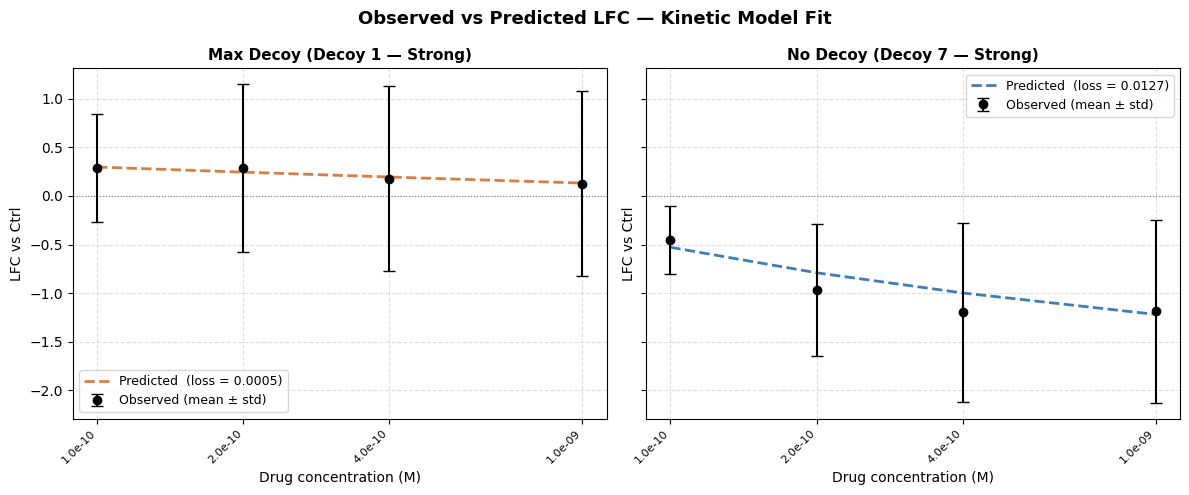

In [47]:
fit.plot_fit_comparison(
    max_decoy_data         = max_decoy_class,
    no_decoy_data          = no_decoy_class,
    best_fit_maxdecoy      = best_fit_maxdecoy,
    best_fit_nodecoy       = best_fit_nodecoy,
    fit_dictionary_maxdecoy= fit_dictionary_maxdecoy,
    fit_dictionary_nodecoy = fit_dictionary_nodecoy,
    drug_conc              = DRUG_CONCENTRATIONS[1:],
    real_concentrations    = DRUG_CONCENTRATIONS_raw[1:],
    model_name_maxdecoy    = 'k3[linear_decrease]__4nodes',
    model_name_nodecoy     = 'k3[linear_decrease]__4nodes',
)